In [1]:
import pandas as pd

# --- Load the cleaned and transformed dataset ---
df = pd.read_csv("merged_data.csv")
df.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


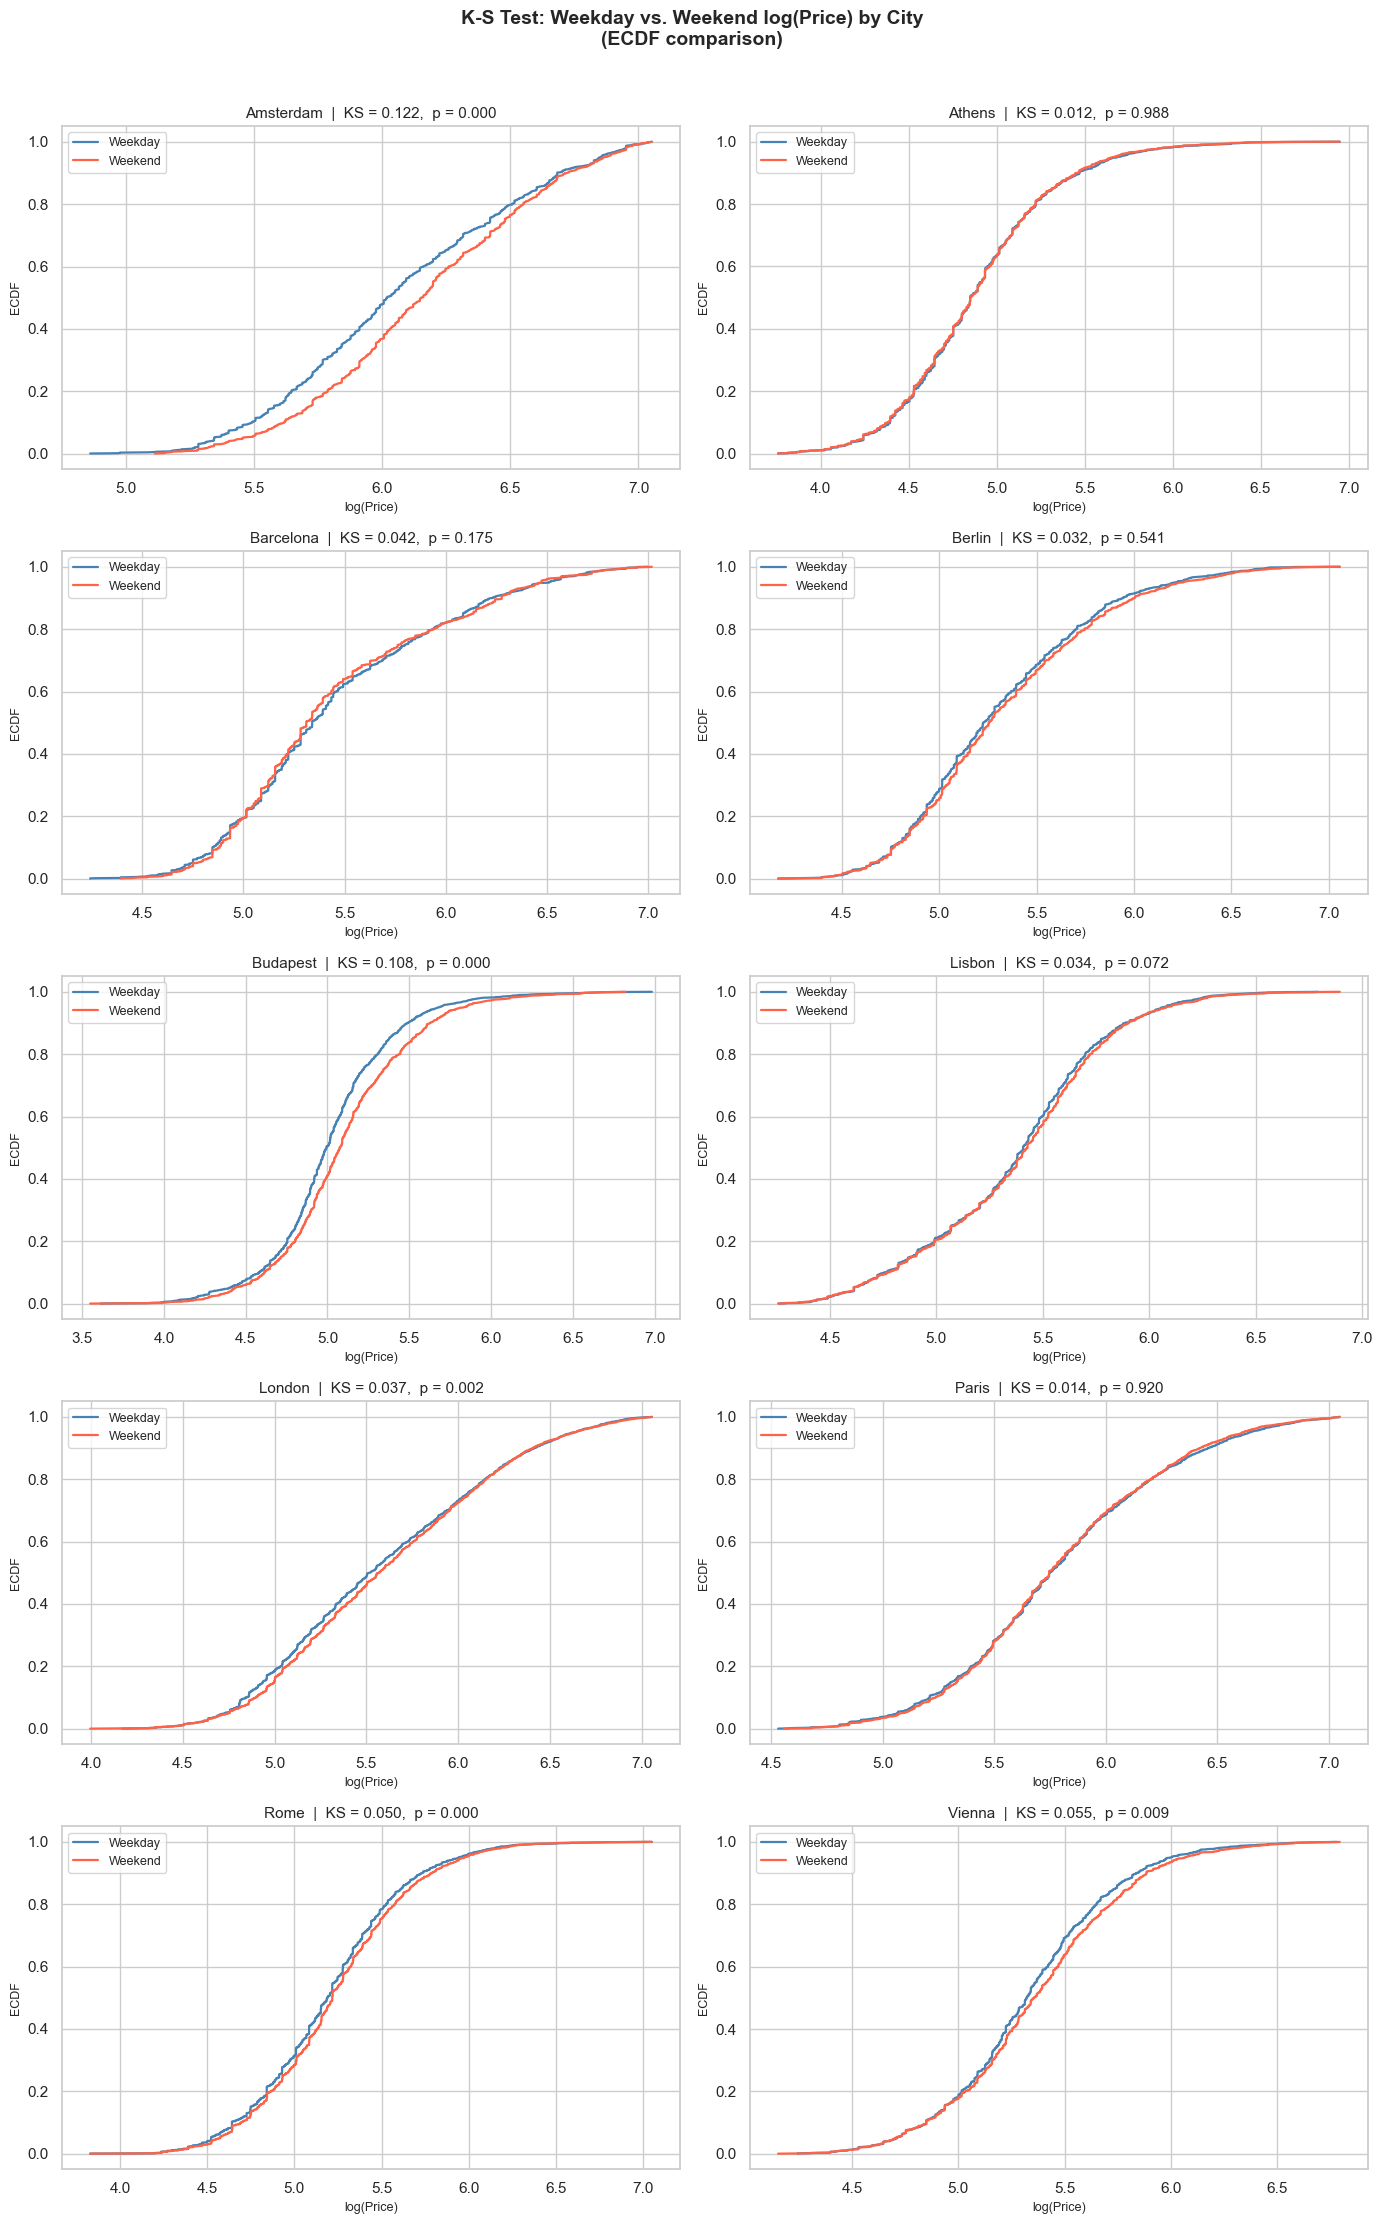

K-S Test Results: Weekday vs. Weekend logSum


,KS Stat,p-value,n weekday,n weekend
City,,,,
Amsterdam,0.122,0.000,1043,901
Athens,0.012,0.988,2652,2627
Barcelona,0.042,0.175,1548,1264
Berlin,0.032,0.541,1277,1193
Budapest,0.108,0.000,2071,1945
Lisbon,0.034,0.072,2855,2905
London,0.037,0.002,4525,5268
Paris,0.014,0.920,3071,3500
Rome,0.050,0.000,4484,4526


In [2]:
# --- K-S test: weekday vs. weekend logSum per city ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

CITY_NAMES = {
    1: 'Amsterdam', 2: 'Athens',    3: 'Barcelona', 4: 'Berlin',
    5: 'Budapest',  6: 'Lisbon',    7: 'London',    8: 'Paris',
    9: 'Rome',      10: 'Vienna'
}

ks_results = []

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for idx, (city_id, city_name) in enumerate(CITY_NAMES.items()):
    city_df   = df[df['city'] == city_name]
    weekday   = city_df[city_df['is_weekday'] == 1]['logSum'].values
    weekend   = city_df[city_df['is_weekday'] == 0]['logSum'].values

    ks_stat, p_value = stats.ks_2samp(weekday, weekend)
    ks_results.append({
        'City':     city_name,
        'KS Stat':  round(ks_stat, 3),
        'p-value':  round(p_value, 3),
        'n weekday': len(weekday),
        'n weekend': len(weekend),
    })

    # Plot ECDFs
    ax = axes[idx]
    for data, label, color in [(weekday, 'Weekday', 'steelblue'),
                                (weekend, 'Weekend', 'tomato')]:
        sorted_data = np.sort(data)
        ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax.plot(sorted_data, ecdf, label=label, color=color, linewidth=1.6)

    ax.set_title(f'{city_name}  |  KS = {ks_stat:.3f},  p = {p_value:.3f}', fontsize=11)
    ax.set_xlabel('log(Price)', fontsize=9)
    ax.set_ylabel('ECDF', fontsize=9)
    ax.legend(fontsize=9)

fig.suptitle('K-S Test: Weekday vs. Weekend log(Price) by City\n(ECDF comparison)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/section2_PlotHypothesis1_weekdayWeekendKS.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
ks_df = pd.DataFrame(ks_results).set_index('City')
print("K-S Test Results: Weekday vs. Weekend logSum")
display(ks_df)


Levene's Test — Equality of Variances (logSum across cities)
  W = 274.558,   p = 0.000
  Conclusion: Reject H0: variances differ significantly


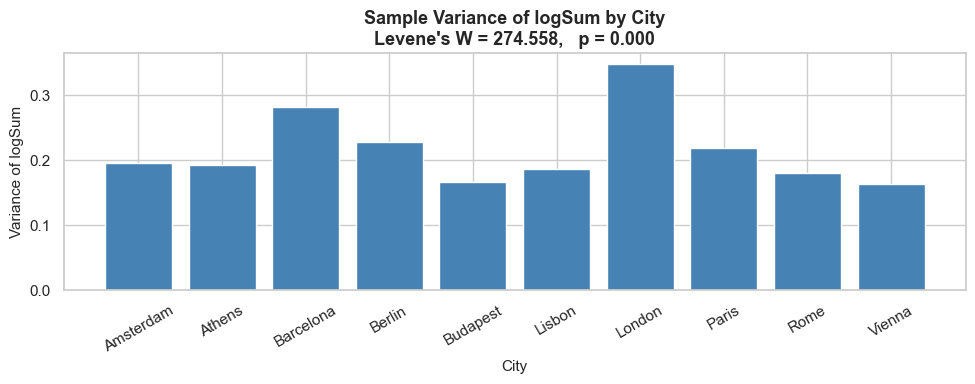

In [3]:
# --- Levene's Test: Equality of Variance in log(Price) Across Cities ---
city_groups = [df[df['city'] == CITY_NAMES[cid]]['logSum'].values for cid in sorted(CITY_NAMES)]
lev_stat, lev_p = stats.levene(*city_groups)

print("=" * 60)
print("Levene's Test — Equality of Variances (logSum across cities)")
print(f"  W = {lev_stat:.3f},   p = {lev_p:.3f}")
sig = "Reject H0: variances differ significantly" if lev_p < 0.05 else "Fail to reject H0"
print(f"  Conclusion: {sig}")
print("=" * 60)

# Per-city variance bar chart
city_vars = {
    CITY_NAMES[cid]: df[df['city'] == CITY_NAMES[cid]]['logSum'].var(ddof=1)
    for cid in sorted(CITY_NAMES)
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(city_vars.keys(), city_vars.values(), color='steelblue', edgecolor='white')
ax.set_title(
    f"Sample Variance of logSum by City\n"
    f"Levene's W = {lev_stat:.3f},   p = {lev_p:.3f}",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("Variance of logSum", fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('plots/section2_PlotHypothesis2_cityVarianceLevene.png', dpi=300, bbox_inches='tight')
plt.show()

Chi-square Test of Independence: Room Type x City
  chi^2 = 9287.475,   df = 18,   p = 0.000
  Conclusion: Reject H0: room type distribution differs by city

Contingency Table (counts):


room_type_cat,Entire apt,Private room,Shared room
city,,,
Amsterdam,1001,933,10
Athens,4871,397,11
Barcelona,524,2276,12
Berlin,870,1527,73
Budapest,3583,419,14
Lisbon,3875,1811,74
London,4215,5528,50
Paris,4960,1517,94
Rome,5547,3451,12


Chi-square Test of Independence: Room Type x Weekday/Weekend
  chi^2 = 3.621,   df = 2,   p = 0.164
  Conclusion: Fail to reject H0

Contingency Table (counts):


room_type_cat,Entire apt,Private room,Shared room
is_weekday,,,
Weekday,15784,9298,180
Weekend,16408,9333,186


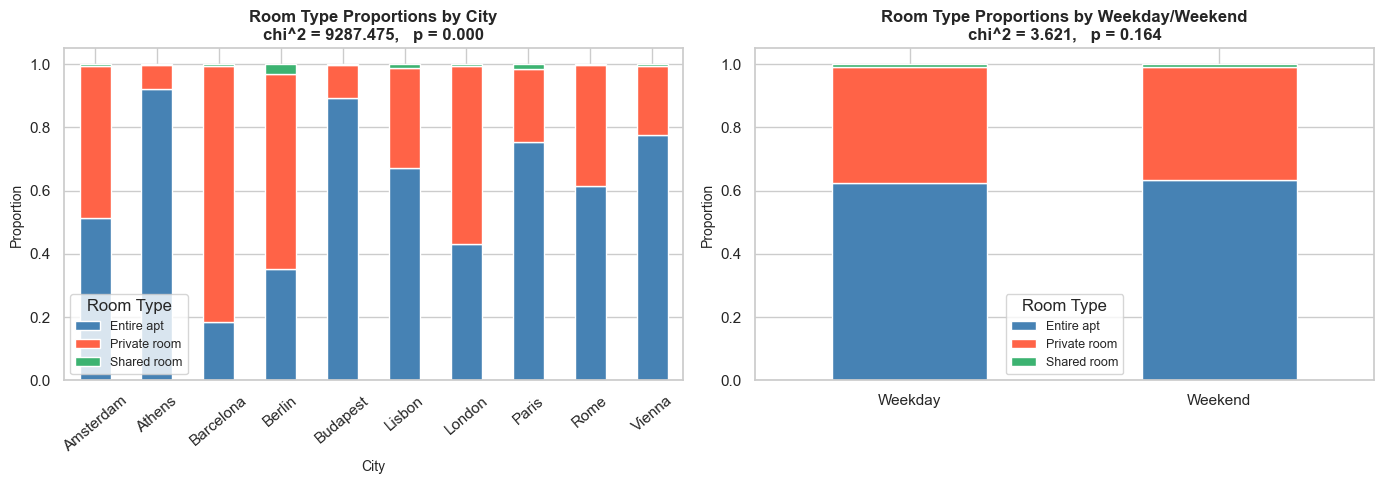

In [4]:
# --- Chi-square tests of Independence ---

# --- Reconstruct room_type categorical column from dummies ---
room_col_map = {
    'room_type_apt':     'Entire apt',
    'room_type_private': 'Private room',
    'room_type_shared':  'Shared room',
}
df['room_type_cat'] = (
    df[['room_type_apt', 'room_type_private', 'room_type_shared']]
    .idxmax(axis=1)
    .map(room_col_map)
)

# --- 1. Room Type x City ---
ct_city = pd.crosstab(df['city'], df['room_type_cat'])
chi2_city, p_city, dof_city, _ = stats.chi2_contingency(ct_city)

print("=" * 60)
print("Chi-square Test of Independence: Room Type x City")
print(f"  chi^2 = {chi2_city:.3f},   df = {dof_city},   p = {p_city:.3f}")
sig_city = "Reject H0: room type distribution differs by city" if p_city < 0.05 else "Fail to reject H0"
print(f"  Conclusion: {sig_city}")
print("=" * 60)
print("\nContingency Table (counts):")
display(ct_city)

# --- 2. Room Type x Weekday/Weekend ---
ct_week = pd.crosstab(
    df['is_weekday'].map({1: 'Weekday', 0: 'Weekend'}),
    df['room_type_cat']
)
chi2_week, p_week, dof_week, _ = stats.chi2_contingency(ct_week)

print("=" * 60)
print("Chi-square Test of Independence: Room Type x Weekday/Weekend")
print(f"  chi^2 = {chi2_week:.3f},   df = {dof_week},   p = {p_week:.3f}")
sig_week = "Reject H0: room type distribution differs by period" if p_week < 0.05 else "Fail to reject H0"
print(f"  Conclusion: {sig_week}")
print("=" * 60)
print("\nContingency Table (counts):")
display(ct_week)

# --- Stacked proportion bar charts ---
room_colors = ['steelblue', 'tomato', 'mediumseagreen']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_city.div(ct_city.sum(axis=1), axis=0).plot(
    kind='bar', stacked=True, ax=axes[0],
    color=room_colors, edgecolor='white'
)
axes[0].set_title(
    f"Room Type Proportions by City\nchi^2 = {chi2_city:.3f},   p = {p_city:.3f}",
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel("City", fontsize=10)
axes[0].set_ylabel("Proportion", fontsize=10)
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(title='Room Type', fontsize=9)

ct_week.div(ct_week.sum(axis=1), axis=0).plot(
    kind='bar', stacked=True, ax=axes[1],
    color=room_colors, edgecolor='white'
)
axes[1].set_title(
    f"Room Type Proportions by Weekday/Weekend\nchi^2 = {chi2_week:.3f},   p = {p_week:.3f}",
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel("", fontsize=10)
axes[1].set_ylabel("Proportion", fontsize=10)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Room Type', fontsize=9)

plt.tight_layout()
plt.savefig('plots/section2_PlotHypothesis3_roomTypeChiSquare.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# --- Two-sample t-test: Superhost Premium on log(Price) ---
superhost     = df[df['is_superhost'] == 1]['logSum'].values
non_superhost = df[df['is_superhost'] == 0]['logSum'].values

t_stat, t_p = stats.ttest_ind(superhost, non_superhost, equal_var=False)  # Welch's t-test

mean_sh  = superhost.mean()
mean_nsh = non_superhost.mean()

pooled_std = np.sqrt(
    ((len(superhost) - 1) * superhost.std(ddof=1)**2 +
     (len(non_superhost) - 1) * non_superhost.std(ddof=1)**2) /
    (len(superhost) + len(non_superhost) - 2)
)
cohens_d = (mean_sh - mean_nsh) / pooled_std

print("=" * 65)
print("Welch's t-test — Superhost vs. Non-superhost log(Price)")
print(f"  n superhost     = {len(superhost):,}")
print(f"  n non-superhost = {len(non_superhost):,}")
print(f"  Mean log(Price): superhost = {mean_sh:.3f},  non-superhost = {mean_nsh:.3f}")
print(f"  t = {t_stat:.3f},   p = {t_p:.3f}")
print(f"  Cohen's d = {cohens_d:.3f}")
sig_sh = "Reject H0: superhost listings command a significant premium" if t_p < 0.05 else "Fail to reject H0"
print(f"  Conclusion: {sig_sh}")
print("=" * 65)

Welch's t-test — Superhost vs. Non-superhost log(Price)
  n superhost     = 13,130
  n non-superhost = 38,059
  Mean log(Price): superhost = 5.331,  non-superhost = 5.422
  t = -16.685,   p = 0.000
  Cohen's d = -0.162
  Conclusion: Reject H0: superhost listings command a significant premium


In [6]:
# --- One-Way ANOVA: Mean log(Price) across 10 cities ---
from statsmodels.stats.multicomp import pairwise_tukeyhsd

city_groups = [df[df['city'] == CITY_NAMES[cid]]['logSum'].values for cid in sorted(CITY_NAMES)]
f_stat, anova_p = stats.f_oneway(*city_groups)

# eta^2 effect size: SS_between / SS_total
grand_mean = df['logSum'].mean()
ss_between = sum(
    len(g) * (g.mean() - grand_mean) ** 2 for g in city_groups
)
ss_total = sum(((g - grand_mean) ** 2).sum() for g in city_groups)
eta_sq = ss_between / ss_total

print("=" * 65)
print("One-Way ANOVA — log(Price) across 10 cities")
print(f"  F = {f_stat:.3f},   p = {anova_p:.3f}")
print(f"  eta^2 = {eta_sq:.3f}  ({'large' if eta_sq >= 0.14 else 'medium' if eta_sq >= 0.06 else 'small'} effect)")
sig_anova = "Reject H0: at least one city mean differs" if anova_p < 0.05 else "Fail to reject H0"
print(f"  Conclusion: {sig_anova}")
print("=" * 65)

One-Way ANOVA — log(Price) across 10 cities
  F = 2242.501,   p = 0.000
  eta^2 = 0.283  (large effect)
  Conclusion: Reject H0: at least one city mean differs


In [7]:
# --- Post-hoc Tukey HSD ---
tukey = pairwise_tukeyhsd(
    endog=df['logSum'],
    groups=df['city'],
    alpha=0.05
)

tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
).rename(columns={'group1': 'City A', 'group2': 'City B',
                   'meandiff': 'Mean Diff', 'p-adj': 'p-adj',
                   'lower': 'CI Lower', 'upper': 'CI Upper',
                   'reject': 'Reject H0'})

sig_pairs = tukey_df[tukey_df['Reject H0'] == True]
print(f"Tukey HSD: {len(sig_pairs)} of {len(tukey_df)} pairs significantly different (alpha=0.05)\n")
print("All pairs (sorted by abs(mean diff)):")
display(
    tukey_df.assign(**{'abs(Mean Diff)': tukey_df['Mean Diff'].abs()})
            .sort_values('abs(Mean Diff)', ascending=False)
            .drop(columns='abs(Mean Diff)')
            .reset_index(drop=True)
)

Tukey HSD: 43 of 45 pairs significantly different (alpha=0.05)

All pairs (sorted by abs(mean diff)):


,City A,City B,Mean Diff,p-adj,CI Lower,CI Upper,Reject H0
0,Amsterdam,Athens,-1.2167,0.0000,-1.2565,-1.1768,True
1,Amsterdam,Budapest,-1.0474,0.0000,-1.0888,-1.0059,True
2,Athens,Paris,0.9018,0.0000,0.8741,0.9296,True
3,Amsterdam,Rome,-0.8925,0.0000,-0.9300,-0.8549,True
4,Amsterdam,Berlin,-0.7855,0.0000,-0.8310,-0.7399,True
5,Amsterdam,Vienna,-0.7542,0.0000,-0.7966,-0.7118,True
6,Budapest,Paris,0.7325,0.0000,0.7025,0.7626,True
7,Amsterdam,Lisbon,-0.7308,0.0000,-0.7702,-0.6914,True
8,Athens,London,0.7074,0.0000,0.6818,0.7330,True
9,Amsterdam,Barcelona,-0.6564,0.0000,-0.7007,-0.6121,True
